# 27 Oct 2024

# *Timeseries*
*Analyse*-->Previous data loading-->
cleaning-->
**eda visualisation**(line plots, seasonal plots)-->
statistics**(ADF** Test-hypothesis testing)-->
**Time Series Decomposition/**Splitting(trend, seasonality, stationarity, noise/residuals)-->
**Auto Correlation Analysis**-->
**ARIMA:: Auto-ARIMA**-->
**Evaluation** ::R2, R2me, MSME Cross Validation to improve the model-->
**SARIMAX MODEL** uses a more dedicated way for auto-Arima i.e. using **Ensemble** learning i.e. 2 or more models combined together-->
**PROPHET model** it is a Deep learning model from facebook

In [ ]:
!pip install yfinance

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Step1: Loading the data
# Download from website

df = yf.download('MSFT',start = '2019-01-01',end = '2024-01-01')
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,,
2019-01-02 00:00:00+00:00,95.310547,101.120003,101.750000,98.940002,99.550003,35329300
2019-01-03 00:00:00+00:00,91.804268,97.400002,100.190002,97.199997,100.099998,42579100
2019-01-04 00:00:00+00:00,96.074013,101.930000,102.510002,98.930000,99.720001,44060600
2019-01-07 00:00:00+00:00,96.196533,102.059998,103.269997,100.980003,101.639999,35656100
2019-01-08 00:00:00+00:00,96.894051,102.800003,103.970001,101.709999,103.040001,31514400


In [ ]:
df.tail()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,,
2023-12-22 00:00:00+00:00,371.799713,374.579987,375.179993,372.709991,373.679993,17091100
2023-12-26 00:00:00+00:00,371.879120,374.660004,376.940002,373.500000,375.000000,12673100
2023-12-27 00:00:00+00:00,371.293518,374.070007,375.059998,372.809998,373.690002,14905400
2023-12-28 00:00:00+00:00,372.494537,375.279999,376.459991,374.160004,375.369995,14327000
2023-12-29 00:00:00+00:00,373.248901,376.040009,377.160004,373.480011,376.000000,18723000


In [ ]:
# look through the data: structural analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2019-01-02 00:00:00+00:00 to 2023-12-29 00:00:00+00:00
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, MSFT)  1258 non-null   float64
 1   (Close, MSFT)      1258 non-null   float64
 2   (High, MSFT)       1258 non-null   float64
 3   (Low, MSFT)        1258 non-null   float64
 4   (Open, MSFT)       1258 non-null   float64
 5   (Volume, MSFT)     1258 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.8 KB


In [ ]:
#shape
df.shape

(1258, 6)

In [ ]:
# per year working index
1258/5
# so 252 is our year working days

251.6

# Step 2: Data Cleaning

In [ ]:
# Missing values

df.isnull().sum()

,,0
Price,Ticker,
Adj Close,MSFT,0
Close,MSFT,0
High,MSFT,0
Low,MSFT,0
Open,MSFT,0
Volume,MSFT,0


In [ ]:
# convert index to datetime
df.index = pd.to_datetime(df.index).date
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT
2019-01-02,95.310547,101.120003,101.750000,98.940002,99.550003,35329300
2019-01-03,91.804268,97.400002,100.190002,97.199997,100.099998,42579100
2019-01-04,96.074013,101.930000,102.510002,98.930000,99.720001,44060600
2019-01-07,96.196533,102.059998,103.269997,100.980003,101.639999,35656100
2019-01-08,96.894051,102.800003,103.970001,101.709999,103.040001,31514400


In [ ]:
# Step 2.2 : Additional Features -

# For Moving average

df['Moving_Average'] = df['Close'].rolling(window = 20).mean()
df.head(50)

Price,Adj Close,Close,High,Low,Open,Volume,Moving_Average
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT,
2019-01-02,95.310547,101.120003,101.750000,98.940002,99.550003,35329300,NaN
2019-01-03,91.804268,97.400002,100.190002,97.199997,100.099998,42579100,NaN
2019-01-04,96.074013,101.930000,102.510002,98.930000,99.720001,44060600,NaN
2019-01-07,96.196533,102.059998,103.269997,100.980003,101.639999,35656100,NaN
2019-01-08,96.894051,102.800003,103.970001,101.709999,103.040001,31514400,NaN
2019-01-09,98.279579,104.269997,104.879997,103.239998,103.860001,32280800,NaN
2019-01-10,97.648064,103.599998,103.750000,102.379997,103.220001,30067600,NaN
2019-01-11,96.894051,102.800003,103.440002,101.639999,103.190002,28314200,NaN
2019-01-14,96.187119,102.050003,102.870003,101.260002,101.900002,28437100,NaN


In [ ]:
# Changes
df['Returns'] = df['Close'].pct_change()
df['Log_Returns'] = np.log(df['Close']/df['Close'].shift(1))
df.head()

Price,Adj Close,Close,High,Low,Open,Volume,Moving_Average,Returns,Log_Returns
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT,,,
2019-01-02,95.310547,101.120003,101.750000,98.940002,99.550003,35329300,NaN,NaN,NaN
2019-01-03,91.804268,97.400002,100.190002,97.199997,100.099998,42579100,NaN,-0.036788,-0.037482
2019-01-04,96.074013,101.930000,102.510002,98.930000,99.720001,44060600,NaN,0.046509,0.045460
2019-01-07,96.196533,102.059998,103.269997,100.980003,101.639999,35656100,NaN,0.001275,0.001275
2019-01-08,96.894051,102.800003,103.970001,101.709999,103.040001,31514400,NaN,0.007251,0.007225


In [ ]:
# volatility for window

df['Volatility'] = df['Returns'].rolling(window = 20).std()
df.head(20)

Price,Adj Close,Close,High,Low,Open,Volume,Moving_Average,Returns,Log_Returns,Volatility
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT,,,,
2019-01-02,95.310547,101.120003,101.750000,98.940002,99.550003,35329300,NaN,NaN,NaN,NaN
2019-01-03,91.804268,97.400002,100.190002,97.199997,100.099998,42579100,NaN,-0.036788,-0.037482,NaN
2019-01-04,96.074013,101.930000,102.510002,98.930000,99.720001,44060600,NaN,0.046509,0.045460,NaN
2019-01-07,96.196533,102.059998,103.269997,100.980003,101.639999,35656100,NaN,0.001275,0.001275,NaN
2019-01-08,96.894051,102.800003,103.970001,101.709999,103.040001,31514400,NaN,0.007251,0.007225,NaN
2019-01-09,98.279579,104.269997,104.879997,103.239998,103.860001,32280800,NaN,0.014300,0.014198,NaN
2019-01-10,97.648064,103.599998,103.750000,102.379997,103.220001,30067600,NaN,-0.006426,-0.006446,NaN
2019-01-11,96.894051,102.800003,103.440002,101.639999,103.190002,28314200,NaN,-0.007722,-0.007752,NaN
2019-01-14,96.187119,102.050003,102.870003,101.260002,101.900002,28437100,NaN,-0.007296,-0.007322,NaN


In [ ]:
df.tail()

Price,Adj Close,Close,High,Low,Open,Volume,Moving_Average,Returns,Log_Returns,Volatility
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT,,,,
2023-12-22,371.799713,374.579987,375.179993,372.709991,373.679993,17091100,373.529001,0.002784,0.002780,0.009791
2023-12-26,371.879120,374.660004,376.940002,373.500000,375.000000,12673100,373.331502,0.000214,0.000214,0.009759
2023-12-27,371.293518,374.070007,375.059998,372.809998,373.690002,14905400,372.900002,-0.001575,-0.001576,0.009391
2023-12-28,372.494537,375.279999,376.459991,374.160004,375.369995,14327000,372.721501,0.003235,0.003229,0.009192
2023-12-29,373.248901,376.040009,377.160004,373.480011,376.000000,18723000,372.578001,0.002025,0.002023,0.009207


In [ ]:
# remove the missing values

df.dropna(inplace = True)
df.head()

Price,Adj Close,Close,High,Low,Open,Volume,Moving_Average,Returns,Log_Returns,Volatility
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT,,,,
2019-01-31,98.430374,104.430000,105.220001,103.180000,103.800003,55636400,104.2860,-0.018330,-0.018501,0.020256
2019-02-01,96.875175,102.779999,104.099998,102.349998,103.779999,35535700,104.5550,-0.015800,-0.015926,0.018630
2019-02-04,99.665108,105.739998,105.800003,102.769997,102.870003,31315100,104.7455,0.028799,0.028392,0.016774
2019-02-05,101.060089,107.220001,107.269997,105.959999,106.059998,27325400,105.0035,0.013997,0.013900,0.016986
2019-02-06,99.938461,106.029999,107.000000,105.529999,107.000000,20609800,105.1650,-0.011099,-0.011161,0.017216


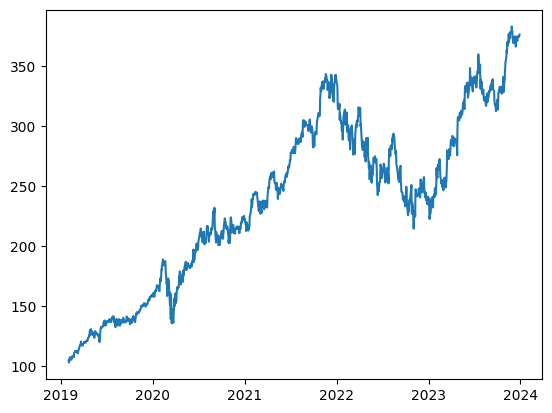

In [ ]:
# step 3: EDA - with help of visuals

plt.plot(df.index, df['Close'])
plt.show()
#

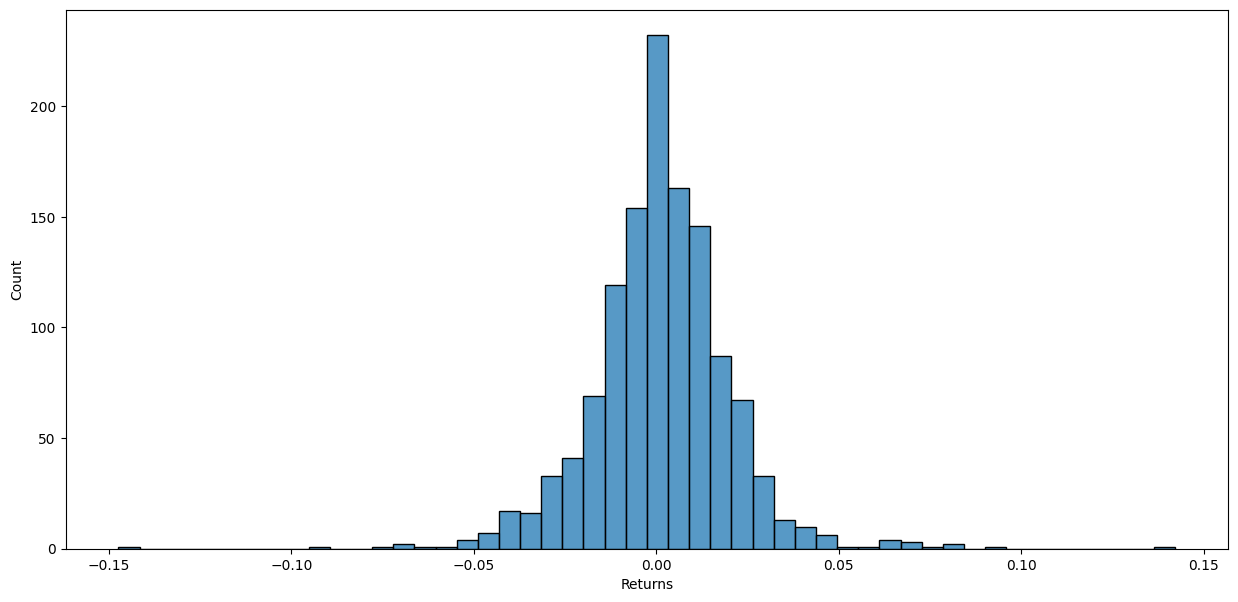

In [ ]:
# returns plot
plt.figure(figsize = (15,7))

sns.histplot(df['Returns'],bins = 50)
plt.show()

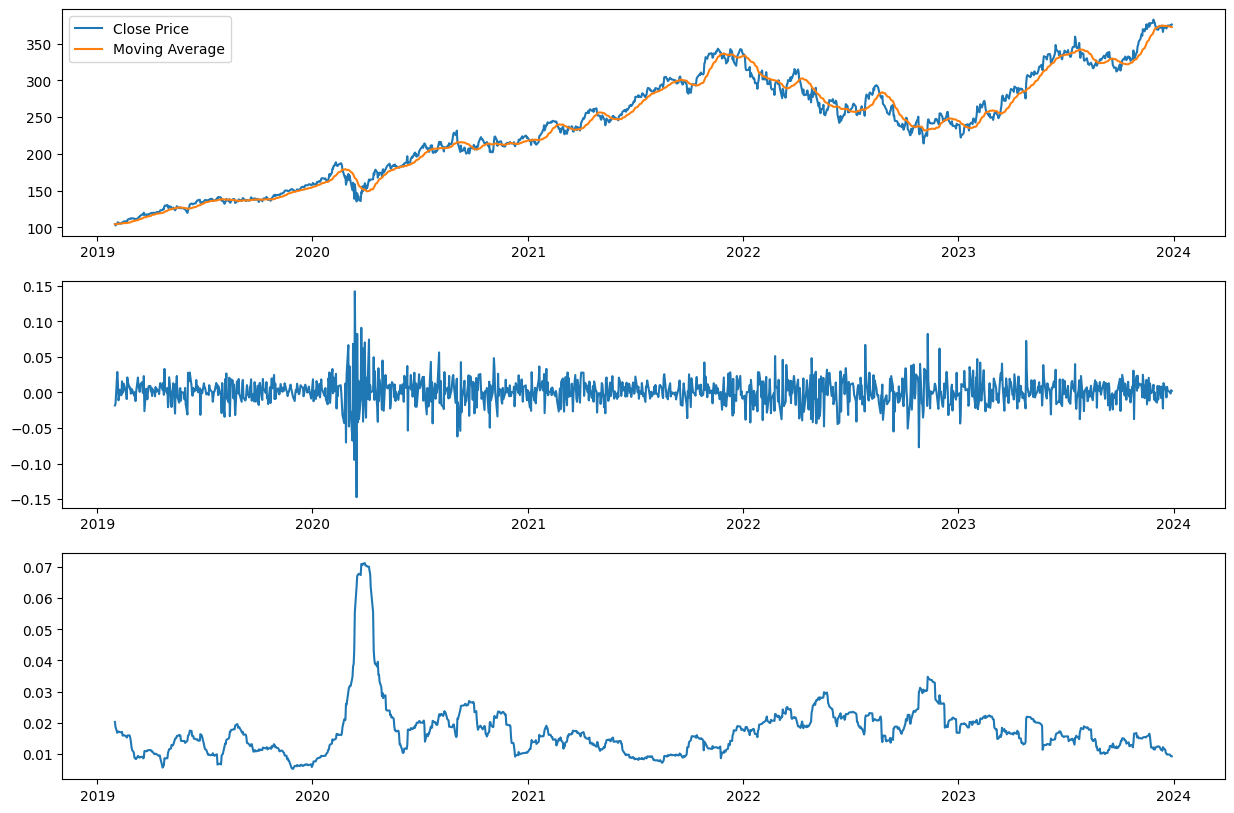

In [ ]:
# create subplots for 3 other metrics
fig,axes = plt.subplots(3,1,figsize = (15,10))
axes[0].plot(df.index,df['Close'],label = 'Close Price')
axes[0].plot(df.index,df['Moving_Average'],label = 'Moving Average')
axes[0].legend()

axes[1].plot(df.index,df['Returns'],label = 'Returns')
#axes[0].plot(df.index,df['Moving_Average'],label = 'Moving Average')

axes[2].plot(df.index,df['Volatility'],label = 'Volatility')

plt.show()

In [ ]:
# Step 4 : Statistical testing techniques: stationarity test

# ADF test

from statsmodels.tsa.stattools import adfuller


In [ ]:
# Perform ADF test
result = adfuller(df['Close'])
print('ADF Statistic: ', result[0])
print('p-value: ',result[1])
print('Critical Values:',result[4])


ADF Statistic:  -0.9064736128033671
p-value:  0.7858330890411438
Critical Values: {'1%': -3.4356863371792095, '5%': -2.8638964938393667, '10%': -2.568024631481501}


### Null hypothesis CAnt be rejected since pvalue is >**.05**

###Stationarity is not there

### Confirmation by looking at ADF stst [-0.9] > critical values

In [ ]:
# Perform ADF test
result = adfuller(df['Returns'])
print('ADF Statistic: ',  result[0])
print('p-value:', result[1])
print('Critical Values:',result[4])


ADF Statistic:  -11.37994475146851
p-value: 8.560204420700456e-21
Critical Values: {'1%': -3.4356819860439574, '5%': -2.863894574114006, '10%': -2.568023609111511}


### My returns are much more stationary than my closing value
### p value is much < 0.05
### Stationarity in nature
### Null hypothesis can be rejectied here

In [ ]:
# Step 5: Time series decomposition

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Close'],period= 252)

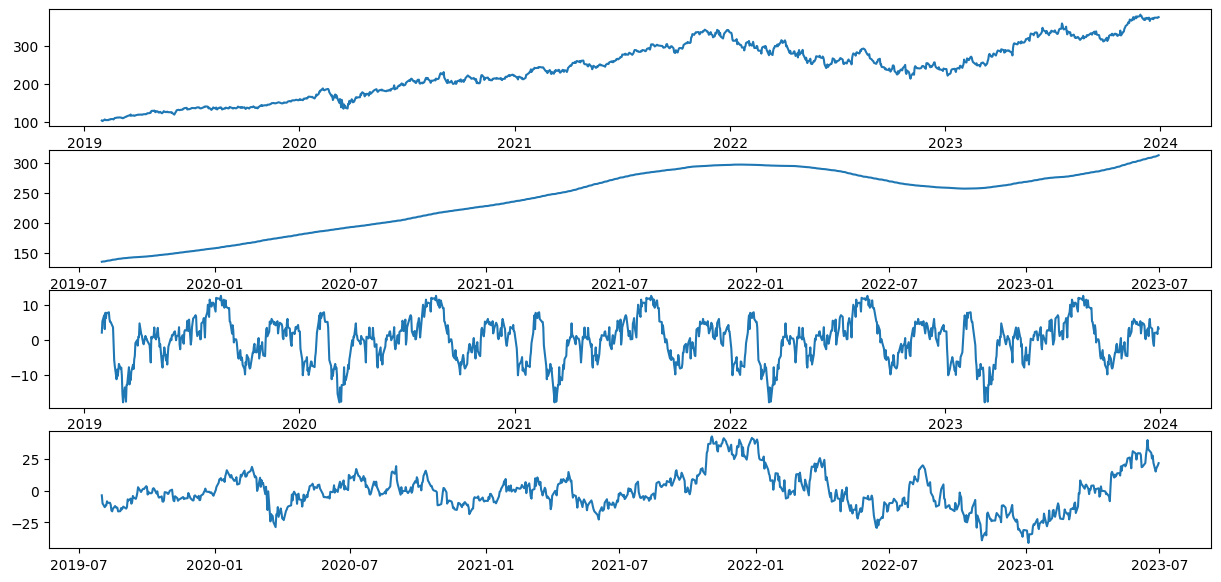

In [ ]:
# plot decomposition
plt.figure(figsize = (15,7))
plt.subplot(411)
plt.plot(df.index,df['Close'])
plt.subplot(412)
plt.plot(decomposition.trend)
plt.subplot(413)
plt.plot(decomposition.seasonal)
plt.subplot(414)
plt.plot(decomposition.resid)

In [ ]:
# Step 6: Auto Correlation Analysis

# ETS-ACF PACF decomposition to UNDERSTAND cyclic component or to understand variation i.e. fluctuation in time series data

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Figure size 1500x700 with 0 Axes>

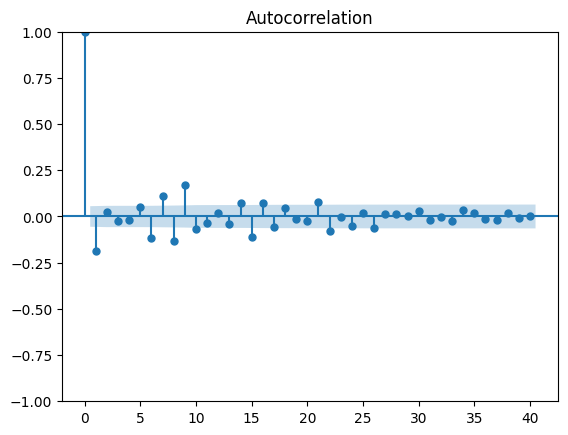

In [ ]:
series = df['Returns']
plt.figure(figsize = (15,7))

plot_acf(series,lags = 40)
plt.show()


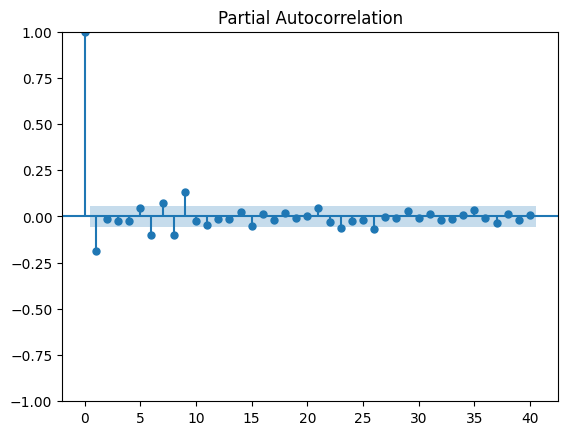

In [ ]:



plot_pacf(series,lags = 40)
plt.show()

In [ ]:
# Step 7 : Data Models - ARIMA

from statsmodels.tsa.arima.model import ARIMA

In [ ]:
# split the data

train_size = int(len(df)*0.8)

train = df['Close'][:train_size]
test = df['Close'][train_size:]

In [ ]:
model = ARIMA(train)
results = model.fit()

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [ ]:
predictions = results.forecast(steps = len(test))

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [ ]:
len(test)

248

In [ ]:
predictions

,predicted_mean
990,219.306627
991,219.306627
992,219.306627
993,219.306627
994,219.306627
...,...
1233,219.306627
1234,219.306627
1235,219.306627
1236,219.306627


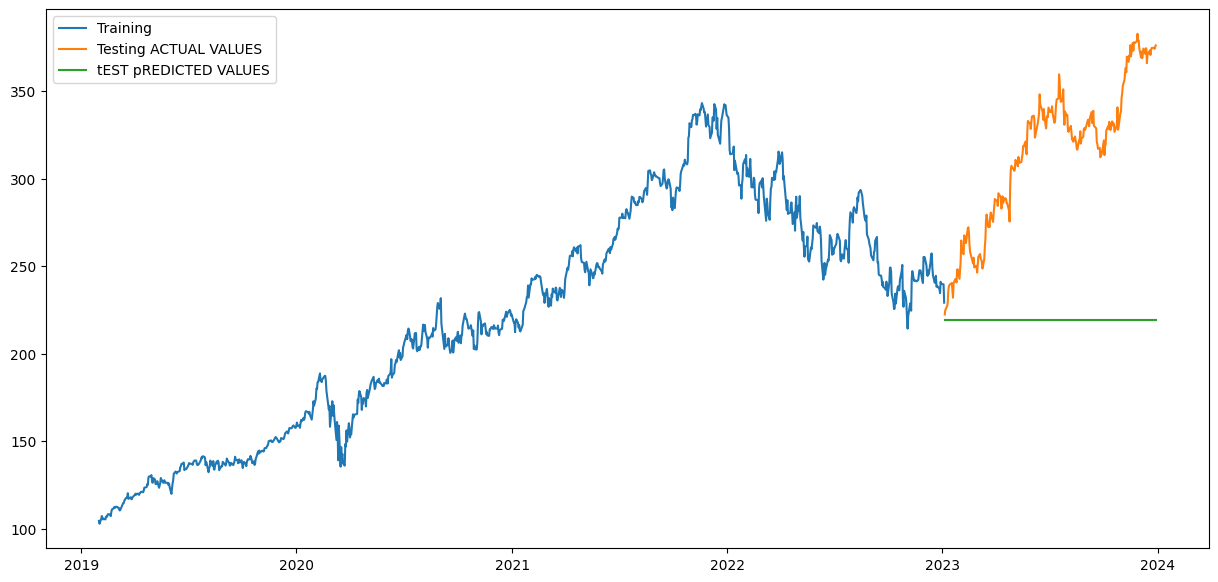

In [ ]:
# Plot the result
plt.figure(figsize = (15,7))
plt.plot(train.index,train,label = 'Training')
plt.plot(test.index,test,label = 'Testing ACTUAL VALUES')
plt.plot(test.index,predictions,label = 'tEST pREDICTED VALUES')
plt.legend()

# evaluation of regressional analysis


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mean_Sq_error = mean_squared_error(test,predictions)
print("mse",mean_Sq_error)

rmse = np.sqrt(mean_Sq_error)
print("rmse",rmse)

r2 = r2_score(test,predictions)
print("r2",r2)

mse 10713.54299555275
rmse 103.50624616685097
r2 -5.556453814101617
